In [2]:
import numpy as np
import pandas as pd

In [3]:
# load data
df=pd.read_csv('startup_funding.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [5]:
df.head(2)

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN


In [6]:
df.drop(columns=['Remarks'],inplace=True)

In [7]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


In [8]:
df.set_index('Sr No')

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
...,...,...,...,...,...,...,...,...
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000"
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000"
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000"


In [9]:
df.rename(columns={'Date dd/mm/yyyy':'date',
                   'Startup Name':'startup',
                   'Industry Vertical':'vertical',
                   'SubVertical':'subvertical',
                   'City  Location':'city',
                   'Investors Name':'investors',
                   'InvestmentnType':'round',
                   'Amount in USD':'amount'
                   },inplace=True)

In [10]:
df

,Sr No,date,startup,vertical,subvertical,city,investors,round,amount
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000"
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000"
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000"
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN


In [11]:
df['amount'] = df['amount'].fillna('0')

In [12]:
df['amount']=df['amount'].str.replace(',','')
df['amount']=df['amount'].str.replace('undisclosed','0')
df['amount']=df['amount'].str.replace('unknown','0')
df['amount']=df['amount'].str.replace('Undisclosed','0')

In [13]:
df = df[df['amount'].str.isdigit()]

In [14]:
df['amount'] = df['amount'].astype('float')

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_14020\843972198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount'] = df['amount'].astype('float')


In [15]:
df.head()

,Sr No,date,startup,vertical,subvertical,city,investors,round,amount
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0


In [16]:
def to_inr(dolllar):
    inr=dolllar*93
    return inr/10000000

In [17]:
df['amount']=df['amount'].apply(to_inr)

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_14020\4236546661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['amount']=df['amount'].apply(to_inr)


In [18]:
df['date'] = df['date'].str.replace('05/072018','05/07/2018')

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_14020\3868201168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['date'].str.replace('05/072018','05/07/2018')


In [19]:
df['date'] = pd.to_datetime(df['date'],errors='coerce')

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_14020\1838826657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'],errors='coerce')


In [20]:
df.sample()

,Sr No,date,startup,vertical,subvertical,city,investors,round,amount
2284,2285,NaT,Superhero Brands,character merchandize sales platform,NaN,Mumbai,DSG Consumer Partners,Seed Funding,5.022


In [21]:
df['date'].dt.year

0       2020.0
1          NaN
2       2020.0
3       2020.0
4       2020.0
         ...  
3039       NaN
3040       NaN
3041       NaN
3042       NaN
3043       NaN
Name: date, Length: 3029, dtype: float64

In [22]:
df=df.dropna(subset=['date','startup','vertical','city','investors','round','amount'])

In [23]:
df.to_csv('startup_clean.csv',index=False)

In [24]:
sorted(set(df['investors'].str.split(',').sum()))

['',
 ' & Others',
 ' 500 Start-Ups',
 ' 500 Startups',
 ' 91springboard',
 ' ABCOM Investments',
 ' AECAL',
 ' AET Fund',
 ' ASP Consulting',
 ' AVN Business Solutions',
 ' Aarin Capital',
 ' Aarin Capital & Others',
 ' Aaruha Technology Fund',
 ' Abaran Deep',
 ' Abhai S. Rao',
 ' Abhay Singhal',
 ' Abhinav Patodia',
 ' Abhishek Goyal',
 ' Abhishek Gupta',
 ' Abhishekh Goyal',
 ' Abstract Ventures',
 ' Accel India',
 ' Accel Partners',
 ' Accel Partners & Others',
 ' Accel Partners and G Raghunandan',
 ' Accel Partners and IDG Ventures',
 ' Accel Partners and Saama Capital',
 ' Accion',
 ' Adam D\\\\xe2\\\\x80\\\\x99Angelo',
 ' Aditya Agarwal',
 ' Aditya Aggarwal',
 ' Aditya Malik & Others',
 ' Aditya Vazirani',
 ' AdvantEdge Partners',
 ' Adveq Management',
 ' Aijaz Saleem',
 ' Ajay Bhatia',
 ' Ajeet Khurana & others',
 ' Akatsuki and Incubate Fund from Japan and Better Capital AngelList syndicate.',
 ' Alfa Capital',
 ' Alok Divatia',
 ' Alok Mittal',
 ' Alok Sharma',
 ' Aloke Bajp

In [25]:
df[df['investors'].str.contains('Beenext')].head()[['date','startup','vertical','city','investors','round','amount']]

,date,startup,vertical,city,investors,round,amount
320,2018-05-03,Wellthy,Healthcare,Mumbai,"Ranjan Pai, Apoorva Patni, Beenext Ventures,Gr...",Private Equity,19.53
529,2017-05-10,Zefo,ECommerce,Bangalore,"Sequoia India, Helion Venture Partners, Beenext",Private Equity,85.56
597,2017-12-09,Get My Parking,Consumer Internet,New Delhi,"IAN Fund, Beenext, Indian Angel Network",Private Equity,27.90
793,2017-04-05,Healthians,Consumer Internet,New Delhi,"Asuka Holdings, YouWeCan Ventures, Beenext, Be...",Private Equity,0.00
883,2017-12-04,HackerEarth,Consumer Internet,Bangalore,"DHI Group Inc, Prime Venture Partners, Beenext...",Private Equity,41.85


In [26]:
df[df['investors'].str.contains('Beenext')].groupby('startup')['amount'].sum().sort_values(ascending=False).head()

startup
Zefo              85.56
IndustryBuying    85.56
Zilingo           74.40
HackerEarth       41.85
Get My Parking    27.90
Name: amount, dtype: float64

In [30]:
df[df['investors'].str.contains('Beenext')].groupby('startup')['amount'].sum().sort_values(ascending=False).head()

startup
Zefo              85.56
IndustryBuying    85.56
Zilingo           74.40
HackerEarth       41.85
Get My Parking    27.90
Name: amount, dtype: float64

<Axes: ylabel='amount'>

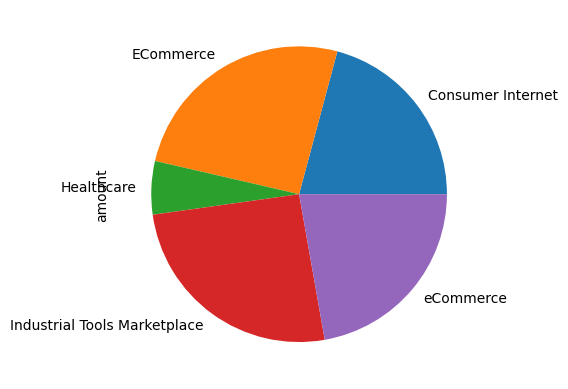

In [41]:
df[df['investors'].str.contains('Beenext')].groupby('vertical')['amount'].sum().plot(kind='pie')

In [46]:
df['Year']=df['date'].dt.year
df

,Sr No,date,startup,vertical,subvertical,city,investors,round,amount,Year
0,1,2020-09-01,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1860.000000,2020
2,3,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,170.737398,2020
3,4,2020-02-01,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.900000,2020
4,5,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.740000,2020
6,7,2020-10-01,Zomato,Hospitality,Online Food Delivery Platform,Gurgaon,Ant Financial,Private Equity Round,1395.000000,2020
...,...,...,...,...,...,...,...,...,...,...
2824,2825,2015-09-04,Urban Ladder,Online Furnishing\\neCommerce,NaN,Bangalore,"Sequoia Capital, TR Capital, Steadview Capital...",Private Equity,465.000000,2015
2825,2826,2015-09-04,Purple Squirrel,Ed-Tech,NaN,Mumbai,"Matrix Partners India, India Quotient",Private Equity,0.000000,2015
2826,2827,2015-10-04,Whatfix,Interactive\\xc2\\xa0 How-To Guides,NaN,Bangalore,"Helion Venture Partner, Powerhouse Ventures, G...",Seed Funding,8.370000,2015
2827,2828,2015-10-04,iMMi Life,Mobile Health Tech,NaN,Chennai,Unitus Seed Fund,Seed Funding,0.000000,2015


<Axes: xlabel='Year'>

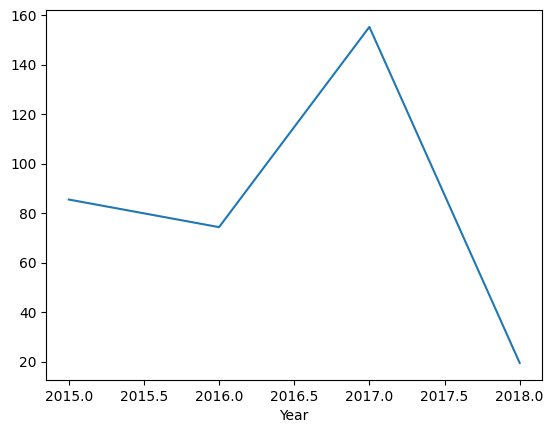

In [47]:
df[df['investors'].str.contains('Beenext')].groupby('Year')['amount'].sum().plot()